# 02. Baseline Model - 스마트 창고 출고 지연 예측

## 전략
1. layout_info 조인
2. 기본 전처리 (범주형 인코딩)
3. LightGBM 5-Fold CV
4. Feature Importance
5. 제출 파일 생성

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings, os

warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


## 1. 데이터 로드

In [2]:
DATA_PATH = '../data/'

train      = pd.read_csv(DATA_PATH + 'train.csv')
test       = pd.read_csv(DATA_PATH + 'test.csv')
layout     = pd.read_csv(DATA_PATH + 'layout_info.csv')
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print(f'Train: {train.shape}, Test: {test.shape}')

Train: (250000, 94), Test: (50000, 93)


## 1-1. Layout 보조 테이블 조인

In [3]:
# layout_info merge (train + test 공통)
layout_cols = [c for c in layout.columns if c != 'layout_id']
print(f'layout 피처 {len(layout_cols)}개 추가: {layout_cols}')

train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

print(f'Train: {train.shape}, Test: {test.shape}')

layout 피처 14개 추가: ['layout_type', 'aisle_width_avg', 'intersection_count', 'one_way_ratio', 'pack_station_count', 'charger_count', 'layout_compactness', 'zone_dispersion', 'robot_total', 'building_age_years', 'floor_area_sqm', 'ceiling_height_m', 'fire_sprinkler_count', 'emergency_exit_count']
Train: (250000, 108), Test: (50000, 107)


## 2. 전처리

In [4]:
# ── 타겟 컬럼 ─────────────────────────────────────────────────
TARGET = 'avg_delay_minutes_next_30m'   # ← 실제 컬럼명

# ── 제외할 ID 컬럼 (명시적으로 지정) ──────────────────────
EXCLUDE_COLS = ['ID', 'layout_id', 'scenario_id', TARGET]

# ── 피처 컬럼 ──────────────────────────────────────────────
feature_cols = [c for c in train.columns if c not in EXCLUDE_COLS]
print(f'피처 수: {len(feature_cols)}')

# ── 범주형 컬럼 처리 (layout_type 등) ────────────────────
cat_cols = train[feature_cols].select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    print(f'범주형 컬럼: {cat_cols}')
    for col in cat_cols:
        combined = pd.concat([train[col], test[col]], axis=0)
        mapping  = {v: i for i, v in enumerate(combined.dropna().unique())}
        train[col] = train[col].map(mapping)
        test[col]  = test[col].map(mapping)

# ── 행렬 변환 ────────────────────────────────────────────
X      = train[feature_cols].values
y      = train[TARGET].values
X_test = test[feature_cols].values

print(f'X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}')
print(f'y 범위: {y.min():.2f} ~ {y.max():.2f}, mean: {y.mean():.2f}')

피처 수: 104
범주형 컬럼: ['layout_type']
X: (250000, 104), y: (250000,), X_test: (50000, 104)
y 범위: 0.00 ~ 715.86, mean: 18.96


## 3. LightGBM Baseline (5-Fold CV)

In [5]:
N_FOLDS = 5
SEED    = 42

params = {
    'objective'      : 'regression',
    'metric'         : 'mae',
    'boosting_type'  : 'gbdt',
    'learning_rate'  : 0.05,
    'num_leaves'     : 63,
    'max_depth'      : -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'   : 5,
    'reg_alpha'      : 0.1,
    'reg_lambda'     : 0.1,
    'verbose'        : -1,
    'n_jobs'         : -1,
    'seed'           : SEED,
}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f'\n--- Fold {fold + 1}/{N_FOLDS} ---')

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_data = lgb.Dataset(X_train, y_train)
    val_data   = lgb.Dataset(X_val,   y_val, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=2000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds        += model.predict(X_test) / N_FOLDS

    fold_mae = mean_absolute_error(y_val, oof_preds[val_idx])
    fold_scores.append(fold_mae)
    print(f'Fold {fold + 1} MAE: {fold_mae:.6f}')

overall_mae = mean_absolute_error(y, oof_preds)
print(f'\n=== Overall OOF MAE: {overall_mae:.6f} ===')
print(f'=== Fold MAEs: {[f"{s:.6f}" for s in fold_scores]} ===')
print(f'=== Std: {np.std(fold_scores):.6f} ===')


--- Fold 1/5 ---


Training until validation scores don't improve for 100 rounds


[200]	valid_0's l1: 8.99157


[400]	valid_0's l1: 8.53462


[600]	valid_0's l1: 8.24815


...

[1400]	valid_0's l1: 7.55154


[1600]	valid_0's l1: 7.44813


[1800]	valid_0's l1: 7.36169


[2000]	valid_0's l1: 7.2802
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 7.2802


Fold 5 MAE: 7.280202

=== Overall OOF MAE: 7.335129 ===
=== Fold MAEs: ['7.308057', '7.379264', '7.300114', '7.408010', '7.280202'] ===
=== Std: 0.049468 ===


## 4. Feature Importance

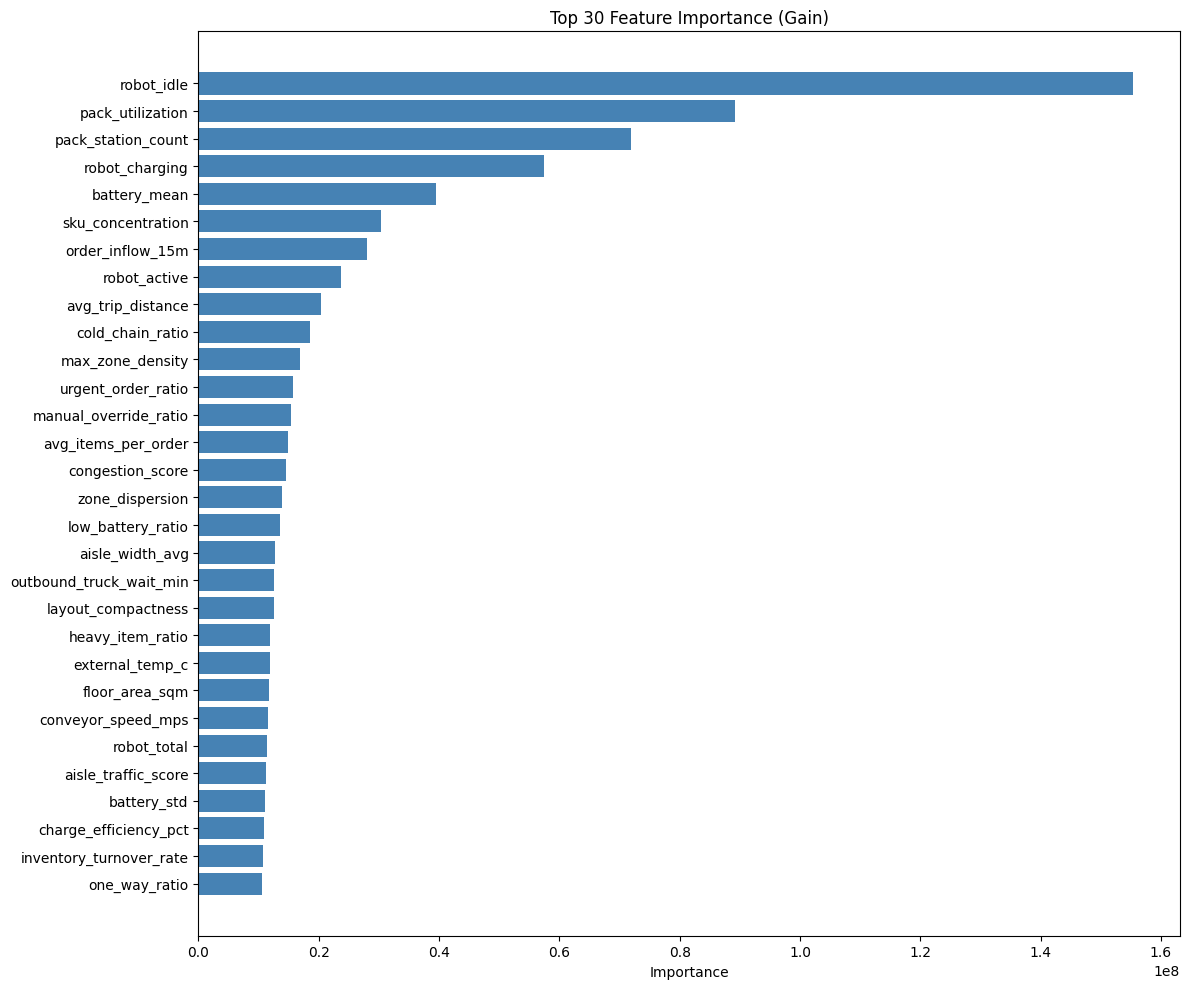

Top 10:
           feature   importance
        robot_idle 1.553964e+08
  pack_utilization 8.926107e+07
pack_station_count 7.191245e+07
    robot_charging 5.750103e+07
      battery_mean 3.944714e+07
 sku_concentration 3.033335e+07
  order_inflow_15m 2.805040e+07
      robot_active 2.371817e+07
 avg_trip_distance 2.035609e+07
  cold_chain_ratio 1.854274e+07


In [6]:
importance = model.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
plt.barh(feat_imp['feature'].head(30), feat_imp['importance'].head(30), color='steelblue')
plt.title('Top 30 Feature Importance (Gain)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/baseline_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 10:')
print(feat_imp.head(10).to_string(index=False))

## 5. 제출 파일 생성

In [7]:
SUBMISSION_COL = 'avg_delay_minutes_next_30m'   # 제출 양식 컬럼명

submission[SUBMISSION_COL] = test_preds

# 음수 클리핑 (출고 지연 시간은 0 이상)
submission[SUBMISSION_COL] = submission[SUBMISSION_COL].clip(lower=0)

SUBMISSION_PATH = '../submissions/'
os.makedirs(SUBMISSION_PATH, exist_ok=True)

filename = f'baseline_lgbm_mae{overall_mae:.4f}.csv'
submission.to_csv(SUBMISSION_PATH + filename, index=False)

print(f'✅ 제출 파일 저장: {filename}')
print(f'   예측값 범위: {submission[SUBMISSION_COL].min():.2f} ~ {submission[SUBMISSION_COL].max():.2f}')
print(f'   예측값 평균: {submission[SUBMISSION_COL].mean():.2f}분')
print(f'   음수 클리핑 수: {(test_preds < 0).sum()}')
print()
submission.head(10)

✅ 제출 파일 저장: baseline_lgbm_mae7.3351.csv
   예측값 범위: 0.00 ~ 129.69
   예측값 평균: 23.27분
   음수 클리핑 수: 24



,ID,avg_delay_minutes_next_30m
0,TEST_000000,16.138952
1,TEST_000001,17.085896
2,TEST_000002,20.346906
3,TEST_000003,18.532419
4,TEST_000004,17.885109
5,TEST_000005,15.786312
6,TEST_000006,14.374831
7,TEST_000007,15.169901
8,TEST_000008,16.634617
9,TEST_000009,21.371497


## 6. 다음 단계 (Day 2→ 순서대로)

### ✅ 오늘 완료 (04.04)
- [x] 타겟 컬럼명 버그 수정 (`avg_delay` → `avg_delay_minutes_next_30m`)
- [x] layout_info.csv 조인 (피처 14개 추가 → 104개)
- [x] 범주형 인코딩 개선 (train+test 합산 매핑)
- [x] 제출 파일 컬럼 검증

### 🔜 04.07 (화) — CV 전략 검증
- [ ] `GroupKFold(groups=scenario_id)` vs `KFold` MAE 비교
- [ ] CV-LB 갭 정량화

### 🔜 04.08 (수) — 로그 변환
- [ ] `log1p(y)` 로 학습 후 `expm1(pred)` 역변환
- [ ] skewness 5.68 → 0.08, MAE 대폭 개선 기대

### 🔜 04.09 (목) — 타임슬롯 피처
- [ ] `ts_idx`, `ts_ratio`, `ts_sin`, `ts_cos` 추가